<a href="https://colab.research.google.com/github/javiermagnone-lab/Javito/blob/main/Taller_obligatorio_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Obligatorio 1**
**- Integrantes:** Valentina Corroti - Guzman Momplet - Javier Magnone
______________________________

**- Repositorio:** https://github.com/javiermagnone-lab/Javito/blob/main/Taller_obligatorio_1.ipynb

**- Diagrama de trabajo**
|#| Sección | Estado|
|---|---|---|
|00| Importarción de librerias y dataset | Finalizado|
|01| Entendimiento del dataset| ¿Finalizado?|
|02| Auditoria de calidad de los datos | Comenzado|
|03| Agrupación por order_id y evaluación de calidad por order_id| Comenzado|
|04| Analisis Univariado | Comenzado|
|05| Analisis Bivariado| No comenzado|



## **00. Importar librerías y carga del dataset**

In [1]:
#Librerías

import pandas as pd
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
!pip install gdown

In [3]:
import gdown

In [4]:
# Carga del dataset
file_id = '1pXy-PVoAIEx4NxqVqtzGhSmI7tupIVHK'

# Descargar el archivo parquet
gdown.download(f'https://drive.google.com/uc?id={file_id}',
               'archivo.parquet', quiet=False)

# Definición del dataset = "df"
df = pd.read_parquet('archivo.parquet')

Downloading...
From (original): https://drive.google.com/uc?id=1pXy-PVoAIEx4NxqVqtzGhSmI7tupIVHK
From (redirected): https://drive.google.com/uc?id=1pXy-PVoAIEx4NxqVqtzGhSmI7tupIVHK&confirm=t&uuid=125c9e56-f920-434d-a6e3-6042f9229e73
To: /content/archivo.parquet
100%|██████████| 2.27G/2.27G [00:28<00:00, 79.8MB/s]


# **01. Entendimiento del dataset**

### *Resumen*

|Tarea | Código | Estado|
|---|---|---|
| Información general | df.info()| Listo
| Lectura del dataset | df.head() | Listo
| Forma del dataset | df.shape| Listo
| Nombres de columnas | df.columns.values.tolist() | Listo
| Tipo de columnas| str(df[col].dtype | Listo
| Total valores por columna | df[col].count()| Listo
| # de nulos en columnas| df[col].isnull().sum()| Listo
| % de nulos en columnas| round(df[col].isnull().mean() * 100, 2)| Listo
| valor mas frecuente en columna| str(top_val) | Listo
| % del valor mas frecuente en columna | top_pct| Listo
| muestra de la columna| df[col].dropna().unique()[:3].tolist()| Listo



In [5]:
# Información general

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15551102 entries, 0 to 15551101
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   order_id            object 
 1   product_id          object 
 2   category            object 
 3   weekday             object 
 4   hour                Int64  
 5   business_type_name  object 
 6   partner_id          object 
 7   user_id             object 
 8   qty_total_products  Int64  
 9   total_amount        float64
 10  has_discount        boolean
 11  is_food             boolean
 12  hist_qc_orders      Int64  
dtypes: Int64(3), boolean(2), float64(1), object(7)
memory usage: 1.4+ GB


In [6]:
#Lectura del dataset

df.head()

,order_id,product_id,category,weekday,hour,business_type_name,partner_id,user_id,qty_total_products,total_amount,has_discount,is_food,hist_qc_orders
0,PpTjCz6Rpezd61n5dPDJTuRqdeuei9ZF179usLRlHDo=,3PhxU90RAhdnzFLvK754zH8dCyaGhx+gRZK6FejN72c=,snacks,Wednesday,2,Kiosks,wGj5g/FyaoIGakOjc8rsSMKLP4ObLso+ToeBLz5gYXA=,MK8B+8oYcJV/UOWHXwSRZKONfUd4BeOoYDlqDfsf6G8=,4,29.047982,True,True,3857
1,b2fkJT7l609B1C5C4mOPpEGmJN9kFsFBEMfA1CFcg+Q=,nW7qzj8ZjWDhm9APVZBpQK+PZ5Rt8kpiJCw9OZ46FPA=,verduras,Wednesday,6,Market,boCBw+WzpRefsURSsXYnYGpr1HAK4RBUHV8hCmvGxGE=,xL2+iPNakXvX1le6s/sXR6QoP2FF44ZYziBWF9wvUNU=,32,185.701304,True,True,871
2,aRM17cbzgUQM2gYrzeKgZF5iPWe+4BoxGZzUR4I9u9M=,EA22Jy/uYTzJrbJZE0v70PUSzzUqzcP9vfWOVOctuJk=,quesos,Friday,7,Market,CSq+DtmiVKcNLprPiiWNTgH5sg97DimLHyswaz3tA5M=,Tk6M9oGhf9s7nUS0Lgf/cYArZLjpsFUnbQzFsQJB2Fc=,39,161.954034,True,True,198
3,ofBqN0N2C1oa7TclCSCS5PTJKTF4DWZJUA85gymH2rY=,P8NwM7gXFCIAeDJdyTCA2+LfcpTOFTi59ASuO7nmymg=,huevos,Friday,7,Market,CSq+DtmiVKcNLprPiiWNTgH5sg97DimLHyswaz3tA5M=,SJ9SEqbIILAEiKPrZ1+18MvW76IDBljdaYCT18wSjWA=,11,32.065813,True,True,246
4,0/7FYlHaqnXz2vaadJWARDRCjxDNRTgguABQXg/mlXc=,9nHMU4b5PPyfTH73olgbjZtx6hvcNtpZFSs1eXUJWb4=,productos de limpieza,Friday,7,Market,T4q47JhNP6vNeE2q/TgmqAJ+QQ1ryCWfr+virSVP8JA=,gI3OKl4ZOAL9N6+RsNfSxwx0oW4Ho3W3jO/KMt9pkqE=,11,25.598921,True,True,233


In [7]:
# Forma del dataset

df.shape

(15551102, 13)

In [8]:
#Lista a las columnas

columns = df.columns.values.tolist()
print(columns)

['order_id', 'product_id', 'category', 'weekday', 'hour', 'business_type_name', 'partner_id', 'user_id', 'qty_total_products', 'total_amount', 'has_discount', 'is_food', 'hist_qc_orders']


In [9]:
# Tabla con descripción general de las columnas

resumen = []
for col in df.columns:
    top_val = df[col].value_counts().idxmax() if df[col].count() > 0 else None
    top_pct = round(df[col].value_counts(normalize=True).max() * 100, 2) if df[col].count() > 0 else None

    resumen.append({
        'columna':             col,
        'tipo':                str(df[col].dtype),
        'total_valores':       df[col].count(),
        'valores_unicos':      df[col].nunique(),
        'nulos':               df[col].isnull().sum(),
        '% nulos':             round(df[col].isnull().mean() * 100, 2),
        'valor_mas_frecuente': str(top_val),
        '% mas_frecuente':     top_pct,
        'muestra':             str(df[col].dropna().unique()[:3].tolist())
    })

resumen_df = pd.DataFrame(resumen).set_index('columna')
resumen_df_original = resumen_df.copy()  # copia fija con nulos para exportar
resumen_df

,tipo,total_valores,valores_unicos,nulos,% nulos,valor_mas_frecuente,% mas_frecuente,muestra
columna,,,,,,,,
order_id,object,15092415,2474292,458687,2.95,cgocQnyCn9TodZwpf/pJyLgcFUkI+pBHWEoOKnAf72s=,0.00,['PpTjCz6Rpezd61n5dPDJTuRqdeuei9ZF179usLRlHDo=...
product_id,object,15551102,1545189,0,0.00,zMD29MXup2v/rYSi9yVqf2/hDUO+O2rmBPbfYrMR8bA=,0.03,['3PhxU90RAhdnzFLvK754zH8dCyaGhx+gRZK6FejN72c=...
category,object,15551102,62,0,0.00,pagnificados,7.57,"['snacks', 'verduras', 'quesos']"
weekday,object,15092415,7,458687,2.95,Sunday,17.78,"['Wednesday', 'Friday', 'Saturday']"
hour,Int64,15092415,24,458687,2.95,19,11.73,"[2, 6, 7]"
business_type_name,object,15092415,3,458687,2.95,Market,94.95,"['Kiosks', 'Market', 'Shop']"
partner_id,object,15092415,2261,458687,2.95,CSq+DtmiVKcNLprPiiWNTgH5sg97DimLHyswaz3tA5M=,2.07,['wGj5g/FyaoIGakOjc8rsSMKLP4ObLso+ToeBLz5gYXA=...
user_id,object,15092415,652879,458687,2.95,l7sBloJsG8eqTemjZSo29Fp6rhirzbKCoy3+hBzUCc4=,0.01,['MK8B+8oYcJV/UOWHXwSRZKONfUd4BeOoYDlqDfsf6G8=...
qty_total_products,Int64,15092415,176,458687,2.95,11,6.13,"[4, 32, 39]"


## **02. Auditoría de calidad de datos**

## *Resumen*
___
General
|Tarea|Utilidad|Estado|
|---|---|---|
| Analizo columnas con nulos según fila | ¿Hay datos faltantes? | Listo|
| Eliminación de filas con nulos | Acción |Listo|
| Busco filas con todas sus columnas iguales | ¿cada registro es unico? |Listo|
| Busco duplicados de order_id + product_id| ¿Las ordenes tienen productos duplicados?|Listo|
| Mapeo de IDs | Facilidad de lectura| Listo
 _____________

Variables cuantitativas
|Tarea|Utilidad|Estado|
|---|---|---
| Impresión de estadisticas básicas | Variables cuantitativas | Listo|
| Boxplot de cuantitativas | Primera visualización | Listo|
| Total_amount = 0 | ¿ Cuantos datos son = $0 ? | Listo|
| Total_amount = 0 | Como se distribuyen según cantidad de productos| Listo|
| Total_amount = 0 | ¿Son ordenes con descuentos? | Listo|
| Total_amount - qty_quantity: Valores muy altos | Selecciono el p99 para analizar mejor | Listo
| Total_amount - qty_quantity: son coherentes los maximos?| Top 10 maximos | Listo|
| Total_amount - qty_quantity: son coherentes los maximos?| Grafico | Listo|
|Total_amount - qty_quantity: Analizo los 4 valores anomalos detectados| ¿presentan algo en común según cats?| Listo
|hist_qc_orders = 19,999 — posible valor de tope artificial?| Analizó cuantos 19.999 hay| Listo
_____________________
Variables categoricas
|Tarea|Utilidad|Estado|
|---|---|---|
|businees_type_name| **Falta**| Falta|
| Category: descripción | Analizo valores unicos: se repiten, idioma, sin datos? | Listo
|Category: comportamiento | Categoria sin valor, ¿como se comporta?| Listo
|Categoy: comportamiento | Cambio dairy (lacteos) y vacios por "Sin Categoria"| Listo
________________________
Variables temporales
|Tarea|Utilidad|Estado|
|---|---|---|
|hour y weekend: cobertura| ¿representan todo el intervalo temporal?|Listo
________________________
Variables booleanas
|Tarea|Utilidad|Estado|
|---|---|---|
|is_food| Falta| Falta|
|has_discount| Falta|Falta|
________________________
Variables IDs
|Tarea|Utilidad|Estado|
|---|---|---|
|User_id| Falta| Falta|
|Product_id| Falta|Falta|
|Partner_id| Falta|Falta|
















In [10]:
# Evaluo si los nulos son filas completas

nulos_por_fila = df.isnull().sum(axis=1)
dist = nulos_por_fila.value_counts().sort_index()

print("" * 45)
print(f"{'Columnas nulas por fila':<25} {'Cantidad de filas':>18}")
print("" * 45)
for n, cant in dist.items():
    pct = cant / len(df) * 100
    print(f"  {n:>2} columnas nulas {'':>10} {cant:>10,}  ({pct:.1f}%)")
print("" * 45)
print(f"\n✓ Solo existen filas con 0 ó {dist.index[-1]} columnas nulas.")
print(f"  Las {dist.iloc[-1]:,} filas sin order_id tienen TODAS")
print(f"  sus columnas de orden en nulo simultáneamente.")



Columnas nulas por fila    Cantidad de filas

   0 columnas nulas            15,092,415  (97.1%)
  11 columnas nulas               458,687  (2.9%)


✓ Solo existen filas con 0 ó 11 columnas nulas.
  Las 458,687 filas sin order_id tienen TODAS
  sus columnas de orden en nulo simultáneamente.


In [11]:
# Elimino las filas que tienen nulos

df_clean = df.dropna(subset=["order_id"]).reset_index (drop=True)
print(f"Filas originales: {len(df):,}")
print(f"Filas eliminadas: {len(df) - len(df_clean):,}")
print(f"Filas restantes: {len(df_clean):,}")

Filas originales: 15,551,102
Filas eliminadas: 458,687
Filas restantes: 15,092,415


In [12]:
# Duplicados exactos (toda la fila igual) - Evaluo erorr de carga del dataset

duplicados = df_clean[df_clean.duplicated(keep=False)]
print(f"Filas duplicadas: {len(duplicados):,}")


Filas duplicadas: 0


In [13]:
# Duplicados por clave: order_id + product_id

dup_clave = df_clean[df_clean.duplicated(subset=['order_id', 'product_id'], keep=False)]
print(f"Filas duplicadas por order_id + product_id: {len(dup_clave):,}")

Filas duplicadas por order_id + product_id: 0


In [14]:
#Copio el dataset

df = df_clean.copy()

In [15]:
# Mapeo de IDs.

id_cols = ['order_id', 'product_id', 'partner_id', 'user_id']

prefijos = {
    'order_id':   'ORD',
    'product_id': 'PRD',
    'partner_id': 'PTN',
    'user_id':    'USR'
}

for col in id_cols:
    mapping = {v: f"{prefijos[col]}_{i+1:05d}" for i, v in enumerate(df[col].unique())}
    df[col] = df[col].map(mapping)
df.head()

,order_id,product_id,category,weekday,hour,business_type_name,partner_id,user_id,qty_total_products,total_amount,has_discount,is_food,hist_qc_orders
0,ORD_00001,PRD_00001,snacks,Wednesday,2,Kiosks,PTN_00001,USR_00001,4,29.047982,True,True,3857
1,ORD_00002,PRD_00002,verduras,Wednesday,6,Market,PTN_00002,USR_00002,32,185.701304,True,True,871
2,ORD_00003,PRD_00003,quesos,Friday,7,Market,PTN_00003,USR_00003,39,161.954034,True,True,198
3,ORD_00004,PRD_00004,huevos,Friday,7,Market,PTN_00003,USR_00004,11,32.065813,True,True,246
4,ORD_00005,PRD_00005,productos de limpieza,Friday,7,Market,PTN_00004,USR_00005,11,25.598921,True,True,233


In [16]:
# Descripción de estadisticas númericas basicas (Variables Cuantitativas)

print("\n=== ESTADÍSTICAS BÁSICAS ===")

print(df[['qty_total_products', 'total_amount', 'hist_qc_orders', 'hour']].describe())


=== ESTADÍSTICAS BÁSICAS ===
       qty_total_products  total_amount  hist_qc_orders        hour
count          15092415.0  1.509242e+07      15092415.0  15092415.0
mean            18.977046  6.569527e+01      578.710221   15.754313
std             15.160155  5.800017e+01      845.945813    4.089791
min                   1.0  0.000000e+00             2.0         0.0
25%                   9.0  2.999390e+01           181.0        12.0
50%                  15.0  4.892241e+01           382.0        16.0
75%                  24.0  8.163226e+01           737.0        19.0
max                 362.0  1.403266e+03         19999.0        23.0


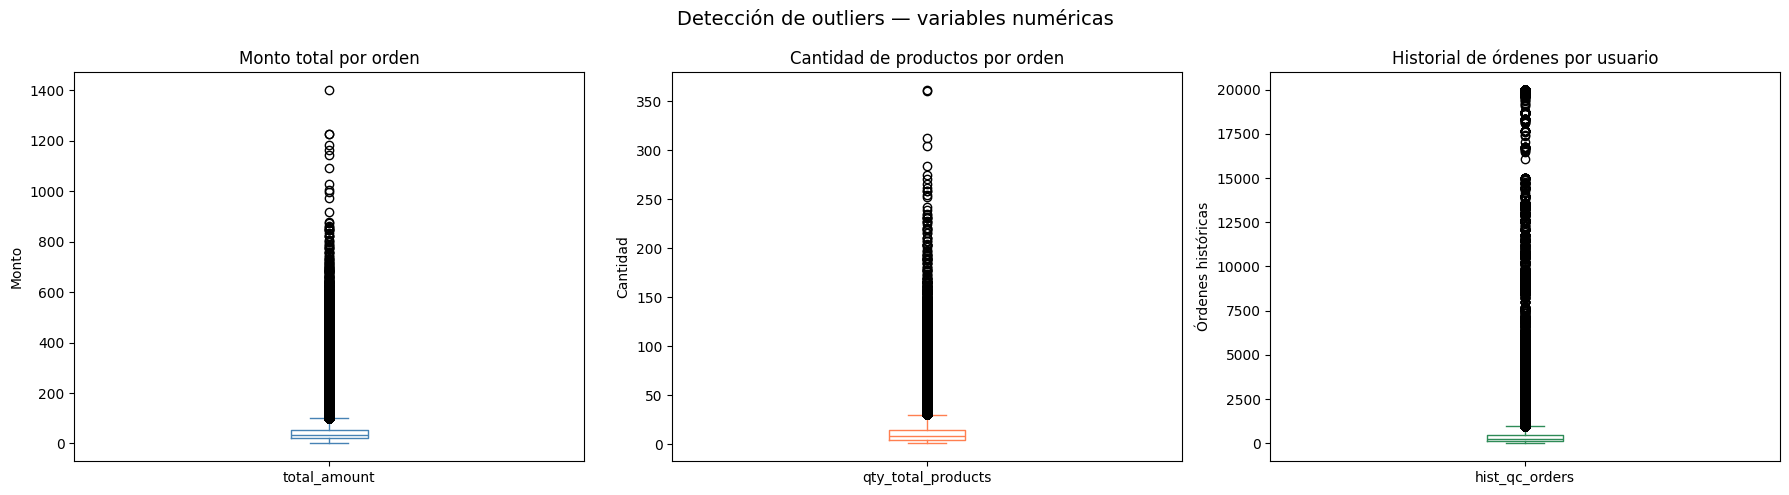

=== OUTLIERS POR MÉTODO IQR ===

total_amount:
  Outliers detectados: 149,591 (6.0%)
  Rango normal: -27.8 a 102.0
  Valor máximo: 1403.3

qty_total_products:
  Outliers detectados: 123,545 (5.0%)
  Rango normal: -10.0 a 30.0
  Valor máximo: 362.0

hist_qc_orders:
  Outliers detectados: 43,589 (6.7%)
  Rango normal: -369.5 a 1002.5
  Valor máximo: 19999.0



In [17]:
# Boxplot de variables cuantitativas

# Boxplots de variables numéricas para detectar outliers
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Total amount (sin extremos para visualizar mejor)
df.groupby('order_id')['total_amount'].first().plot(
    kind='box', ax=axes[0], color='steelblue'
)
axes[0].set_title('Monto total por orden')
axes[0].set_ylabel('Monto')

# Cantidad de productos
df.groupby('order_id')['qty_total_products'].first().plot(
    kind='box', ax=axes[1], color='coral'
)
axes[1].set_title('Cantidad de productos por orden')
axes[1].set_ylabel('Cantidad')

# Historial por usuario
df.groupby('user_id')['hist_qc_orders'].first().plot(
    kind='box', ax=axes[2], color='seagreen'
)
axes[2].set_title('Historial de órdenes por usuario')
axes[2].set_ylabel('Órdenes históricas')

plt.suptitle('Detección de outliers — variables numéricas', fontsize=14)
plt.tight_layout()
plt.show()

# Cuantificación de outliers con método IQR
print("=== OUTLIERS POR MÉTODO IQR ===\n")
for var, grupo in [
    ('total_amount', df.groupby('order_id')['total_amount'].first()),
    ('qty_total_products', df.groupby('order_id')['qty_total_products'].first()),
    ('hist_qc_orders', df.groupby('user_id')['hist_qc_orders'].first())
]:
    Q1 = grupo.quantile(0.25)
    Q3 = grupo.quantile(0.75)
    IQR = Q3 - Q1
    outliers = grupo[(grupo < Q1 - 1.5*IQR) | (grupo > Q3 + 1.5*IQR)]
    print(f"{var}:")
    print(f"  Outliers detectados: {len(outliers):,} ({len(outliers)/len(grupo)*100:.1f}%)")
    print(f"  Rango normal: {Q1 - 1.5*IQR:.1f} a {Q3 + 1.5*IQR:.1f}")
    print(f"  Valor máximo: {grupo.max():.1f}\n")


In [18]:
# Variable Total_amount: Valores = $0, ¿Estan bien esos datos?

total_ordenes = df['order_id'].nunique()
n_cero = df[df['total_amount'] == 0]['order_id'].nunique()
pct_cero = n_cero / total_ordenes * 100

print(f"Total de órdenes:             {total_ordenes:,}")
print(f"Órdenes con total_amount = 0: {n_cero:,}  ({pct_cero:.2f}%)")

Total de órdenes:             2,474,292
Órdenes con total_amount = 0: 5,112  (0.21%)


In [19]:
# Detalle de las órdenes con monto $0

df[df['total_amount'] == 0].drop_duplicates('order_id')[['has_discount', 'business_type_name', 'qty_total_products']].describe()

,qty_total_products
count,5112.0
mean,9.498044
std,7.500003
min,1.0
25%,4.0
50%,8.0
75%,12.0
max,92.0


In [20]:
# Evaluo de las ordenes que tien total_amount = $0, cuantas tienen descuento

df_cero = df[df['total_amount'] == 0].drop_duplicates('order_id')
vc = df_cero['has_discount'].value_counts()
pct = df_cero['has_discount'].value_counts(normalize=True).mul(100).round(2)
pd.DataFrame({'n': vc, '%': pct})

,n,%
has_discount,,
True,5111,99.98
False,1,0.02


- Las ordenes con monto = 0 tienen descuento. No se eliminan



In [21]:
# Percentil 99 de total_amount y qty_total_products (Para mejorar visualización de graficos)

df_ord = df.drop_duplicates('order_id')

for col in ['total_amount', 'qty_total_products']:
    s = df_ord[col]
    p99 = s.quantile(0.99)
    n_sobre = (s > p99).sum()
    pct = n_sobre / len(s) * 100
    print(f"{col}:")
    print(f"  p99         = {p99:.1f}")
    print(f"  sobre p99   = {n_sobre:,}  ({pct:.2f}%)")
    print(f"  máximo      = {s.max():.1f}")
    print()

total_amount:
  p99         = 187.0
  sobre p99   = 24,743  (1.00%)
  máximo      = 1403.3

qty_total_products:
  p99         = 49.0
  sobre p99   = 24,456  (0.99%)
  máximo      = 362.0



In [22]:
#Evaluo como se comporta total_amount con la cantidad de prodocutos de que tiene la orden
# Top 10 órdenes por total_amount — relación con qty_total_products

p99_qty = df_ord['qty_total_products'].quantile(0.99)

top10 = df_ord.nlargest(10, 'total_amount')[
    ['order_id', 'total_amount', 'qty_total_products', 'business_type_name', 'weekday']
].copy()

top10['precio_unitario'] = (top10['total_amount'] / top10['qty_total_products']).round(2)
top10['qty_sobre_p99']   = top10['qty_total_products'] > p99_qty
top10

,order_id,total_amount,qty_total_products,business_type_name,weekday,precio_unitario,qty_sobre_p99
1965354,ORD_619760,1403.265724,5,Market,Monday,280.65,False
481147,ORD_225851,1227.550989,304,Market,Sunday,4.04,True
52932,ORD_43894,1225.920748,262,Market,Wednesday,4.68,True
265391,ORD_163275,1182.623469,126,Market,Saturday,9.39,True
42625,ORD_35265,1162.362889,190,Market,Thursday,6.12,True
53644,ORD_44526,1143.498362,232,Market,Friday,4.93,True
14333992,ORD_2422968,1091.486201,3,Market,Friday,363.83,False
69305,ORD_57180,1028.155778,154,Market,Friday,6.68,True
340854,ORD_189849,1006.150244,203,Market,Sunday,4.96,True
70296,ORD_57984,996.016455,113,Market,Friday,8.81,True


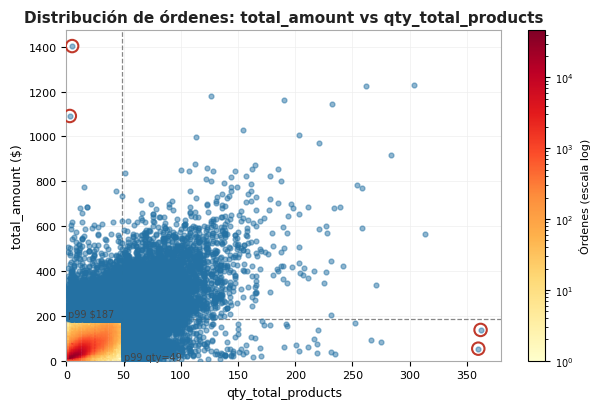

In [23]:
#Realizo grafico total_amount con qty_total_products.  Desde p99 para hacer enfasis en los comportamientos mas altos.

p99_amount = df_ord['total_amount'].quantile(0.99)
p99_qty    = df_ord['qty_total_products'].quantile(0.99)
p50_qty    = df_ord['qty_total_products'].quantile(0.50)

# Masa: dentro del p99 en ambas dimensiones
df_bulk = df_ord[(df_ord['total_amount'] <= p99_amount) & (df_ord['qty_total_products'] <= p99_qty)]

# Extremos: sobre p99 en al menos una dimensión
df_ext = df_ord[(df_ord['total_amount'] > p99_amount) | (df_ord['qty_total_products'] > p99_qty)]

# 4 puntos anómalos
anomalos_precio = df_ord[df_ord['qty_total_products'] < p50_qty].nlargest(2, 'total_amount')
anomalos_qty    = df_ord[df_ord['qty_total_products'] > 350].nsmallest(2, 'total_amount')
anomalos = pd.concat([anomalos_precio, anomalos_qty])

fig, ax = plt.subplots(figsize=(6.3, 4.2), facecolor='white')

hb = ax.hexbin(
    df_bulk['qty_total_products'],
    df_bulk['total_amount'],
    gridsize=50,
    bins='log',
    cmap='YlOrRd',
    mincnt=1,
)

cb = fig.colorbar(hb, ax=ax)
cb.set_label('Órdenes (escala log)', fontsize=8)
cb.ax.tick_params(labelsize=7)

ax.scatter(df_ext['qty_total_products'], df_ext['total_amount'],
           color='#2471A3', s=12, alpha=0.5, zorder=3)

# Círculo rojo hueco sobre los 4 anómalos
ax.scatter(anomalos['qty_total_products'], anomalos['total_amount'],
           facecolors='none', edgecolors='#C0392B', linewidths=1.5, s=80, zorder=6)

ax.axvline(p99_qty,    color='#555555', linewidth=0.9, linestyle='--', alpha=0.7)
ax.axhline(p99_amount, color='#555555', linewidth=0.9, linestyle='--', alpha=0.7)
ax.text(p99_qty + 1,  5, f'p99 qty={p99_qty:.0f}',  fontsize=7, color='#444444')
ax.text(1, p99_amount + 8, f'p99 ${p99_amount:.0f}', fontsize=7, color='#444444')

ax.set_xlim(0, df_ord['qty_total_products'].max() * 1.05)
ax.set_ylim(0, df_ord['total_amount'].max() * 1.05)
ax.set_xlabel('qty_total_products', fontsize=9)
ax.set_ylabel('total_amount ($)', fontsize=9)
ax.set_title('Distribución de órdenes: total_amount vs qty_total_products',
             fontsize=11, fontweight='bold', color='#222222')

for lbl in ax.get_xticklabels() + ax.get_yticklabels():
    lbl.set_fontsize(8)

ax.set_facecolor('white')
ax.grid(color='#EEEEEE', linewidth=0.5)
for spine in ax.spines.values():
    spine.set_edgecolor('#AAAAAA')
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.savefig('hexbin_amount_qty.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

- Hay dos precios muy altos con pocas cantidades de productos
- Hay dos cantidades de productos con precios totales muy bajos

In [24]:
#Los 4 valores anomalos detectados, ¿presentan algo en común?

anomalos[['order_id', 'total_amount', 'qty_total_products', 'partner_id', 'business_type_name', 'weekday']].reset_index(drop=True)

,order_id,total_amount,qty_total_products,partner_id,business_type_name,weekday
0,ORD_619760,1403.265724,5,PTN_00355,Market,Monday
1,ORD_2422968,1091.486201,3,PTN_00067,Market,Friday
2,ORD_305087,53.764470,360,PTN_00268,Market,Friday
3,ORD_205397,137.323400,362,PTN_00282,Market,Friday


In [25]:
# hist_qc_orders = 19,999 — posible valor de tope artificial?

s = df.drop_duplicates('order_id')['hist_qc_orders']

p99  = s.quantile(0.99)
p999 = s.quantile(0.999)

df_cap = df[df['hist_qc_orders'] == 19999].drop_duplicates('order_id')
print(f"p99               = {p99:,.0f}")
print(f"p99.9             = {p999:,.0f}")
print(f"máximo            = {s.max():,.0f}")
print()
print(f"Órdenes con hist_qc_orders = 19,999: {len(df_cap):,}  ({len(df_cap)/s.count()*100:.3f}%)")
print(f"Usuarios únicos con ese valor:        {df[df['hist_qc_orders'] == 19999]['user_id'].nunique():,}")

p99               = 2,852
p99.9             = 12,094
máximo            = 19,999

Órdenes con hist_qc_orders = 19,999: 49  (0.002%)
Usuarios únicos con ese valor:        8


In [26]:
# Variables categoricas: category — revisión de los 62 valores únicos para detectar inconsistencias en valores

cat_counts = df['category'].value_counts().reset_index()
cat_counts.columns = ['category', 'n']
cat_counts['%'] = (cat_counts['n'] / len(df) * 100).round(2)
pd.set_option('display.max_rows', 70)
cat_counts

,category,n,%
0,verduras,1158291,7.67
1,pagnificados,1143331,7.58
2,snacks,888285,5.89
3,lacteos,841429,5.58
4,quesos,826652,5.48
5,bebidas,724438,4.80
6,cuidado personal,624916,4.14
7,frutas,572413,3.79
8,general,569168,3.77
9,condimentos especias,560355,3.71


In [27]:
#La categoria que no tiene valores, como se comporta?

n_vacias   = (df['category'] == '').sum()
n_espacios = df['category'].str.strip().eq('').sum()
total      = len(df)

print(f"Registros con category vacía (''): {n_vacias:,}  ({n_vacias/total*100:.2f}%)")
print(f"Registros con category solo espacios: {n_espacios:,}  ({n_espacios/total*100:.2f}%)")

Registros con category vacía (''): 13,858  (0.09%)
Registros con category solo espacios: 13,858  (0.09%)


In [28]:
# Correcciones de nomenclatura en category (Sin datos y lacteos)

# 1. 'dairy' es equivalente a 'lacteos' — unificación de idioma
n_dairy = (df['category'] == 'dairy').sum()
df['category'] = df['category'].replace('dairy', 'lacteos')

# 2. Categoría vacía → 'Sin categoría'
n_vacias = (df['category'] == '').sum()
df['category'] = df['category'].replace('', 'Sin categoría')

print(f"Registros reclasificados 'dairy'  'lacteos':       {n_dairy:,}")
print(f"Registros reclasificados '' → 'Sin categoría':      {n_vacias:,}")
print(f"Categorías únicas tras correcciones: {df['category'].nunique()}")

Registros reclasificados 'dairy'  'lacteos':       323,454
Registros reclasificados '' → 'Sin categoría':      13,858
Categorías únicas tras correcciones: 61


In [29]:
# Cobertura temporal: verificar que hour y weekday tienen representación completa

df_ord = df.drop_duplicates('order_id')

# -- hour: esperados 0–23 --
horas_presentes = sorted(df_ord['hour'].dropna().unique())
horas_faltantes = [h for h in range(24) if h not in horas_presentes]

print(" hour ")
print(f"Horas distintas cubiertas: {len(horas_presentes)} / 24")
print(f"Horas sin datos:           {horas_faltantes if horas_faltantes else 'ninguna'}")
print()

# Órdenes por hora
conteo_hora = df_ord['hour'].value_counts().sort_index()
min_h, max_h = conteo_hora.min(), conteo_hora.max()
print(f"Hora con menos órdenes: {conteo_hora.idxmin()}h  ({min_h:,} órdenes)")
print(f"Hora con más órdenes:   {conteo_hora.idxmax()}h  ({max_h:,} órdenes)")
print(f"Ratio max/min:          {max_h/min_h:.1f}x")
print()

# -- weekday: esperados 7 días --
dias_presentes = sorted(df_ord['weekday'].dropna().unique())
dias_faltantes = [d for d in ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
                  if d not in dias_presentes]

print(" weekday ")
print(f"Días distintos cubiertos: {len(dias_presentes)} / 7")
print(f"Días sin datos:           {dias_faltantes if dias_faltantes else 'ninguno'}")
print()

conteo_dia = df_ord['weekday'].value_counts()
min_d, max_d = conteo_dia.min(), conteo_dia.max()
print(f"Día con menos órdenes: {conteo_dia.idxmin()}  ({min_d:,} órdenes)")
print(f"Día con más órdenes:   {conteo_dia.idxmax()}  ({max_d:,} órdenes)")
print(f"Ratio max/min:         {max_d/min_d:.1f}x")

 hour 
Horas distintas cubiertas: 24 / 24
Horas sin datos:           ninguna

Hora con menos órdenes: 4h  (120 órdenes)
Hora con más órdenes:   19h  (276,877 órdenes)
Ratio max/min:          2307.3x

 weekday 
Días distintos cubiertos: 7 / 7
Días sin datos:           ninguno

Día con menos órdenes: Wednesday  (300,678 órdenes)
Día con más órdenes:   Sunday  (445,434 órdenes)
Ratio max/min:         1.5x


## **03. Agrupación por order_id**

*Resumen*
|Tarea|Utilidad|Estado|
|---|---|---|
|Agrupación por order_id| Selección por first| Listo
|Comportamiento de la columna según agrupación| ¿Son constantes los valores de cada columna?  | Listo
|Resumen general df_order| Caracteristicas del nuevo df_orders| Listo


In [30]:
# Agrupación por orden (Definición de nuevo df = "df_orders")
# No se crean nuevas variables aún

orden_cols = ["weekday", "hour", "business_type_name", "partner_id", "user_id",
              "qty_total_products", "total_amount", "has_discount", "is_food", "hist_qc_orders"]

df_orders = (
    df.groupby("order_id", sort=False)
    .agg(**{col: (col, "first") for col in orden_cols})
    .reset_index()
)

print(f"Filas en df (producto-orden): {len(df):,}")
print(f"Órdenes únicas en df_orders:  {len(df_orders):,}")
df_orders.head()

Filas en df (producto-orden): 15,092,415
Órdenes únicas en df_orders:  2,474,292


,order_id,weekday,hour,business_type_name,partner_id,user_id,qty_total_products,total_amount,has_discount,is_food,hist_qc_orders
0,ORD_00001,Wednesday,2,Kiosks,PTN_00001,USR_00001,4,29.047982,True,True,3857
1,ORD_00002,Wednesday,6,Market,PTN_00002,USR_00002,32,185.701304,True,True,871
2,ORD_00003,Friday,7,Market,PTN_00003,USR_00003,39,161.954034,True,True,198
3,ORD_00004,Friday,7,Market,PTN_00003,USR_00004,11,32.065813,True,True,246
4,ORD_00005,Friday,7,Market,PTN_00004,USR_00005,11,25.598921,True,True,233


In [31]:
# Verificar que todas las columnas de orden son constantes dentro de cada order_id

order_cols = ['weekday', 'hour', 'business_type_name', 'partner_id', 'user_id',
              'qty_total_products', 'total_amount', 'has_discount', 'is_food', 'hist_qc_orders']

for col in order_cols:
    n_varies = (df.groupby('order_id')[col].nunique() > 1).sum()
    print(f"{col:25s}: {n_varies:,} órdenes con más de un valor")

weekday                  : 0 órdenes con más de un valor
hour                     : 0 órdenes con más de un valor
business_type_name       : 0 órdenes con más de un valor
partner_id               : 0 órdenes con más de un valor
user_id                  : 0 órdenes con más de un valor
qty_total_products       : 0 órdenes con más de un valor
total_amount             : 0 órdenes con más de un valor
has_discount             : 0 órdenes con más de un valor
is_food                  : 0 órdenes con más de un valor
hist_qc_orders           : 0 órdenes con más de un valor


In [33]:
# Tabla con descripción general de las columnas según order_id

resumen_order_id = []
for col in df_orders.columns:
    top_val = df_orders[col].value_counts().idxmax() if df_orders[col].count() > 0 else None
    top_pct = round(df_orders[col].value_counts(normalize=True).max() * 100, 2) if df_orders[col].count() > 0 else None

    resumen_order_id.append({
        'columna':             col,
        'tipo':                str(df_orders[col].dtype),
        'total_valores':       df_orders[col].count(),
        'valores_unicos':      df_orders[col].nunique(),
        'nulos':               df_orders[col].isnull().sum(),
        '% nulos':             round(df_orders[col].isnull().mean() * 100, 2),
        'valor_mas_frecuente': str(top_val),
        '% mas_frecuente':     top_pct,
        'muestra':             str(df_orders[col].dropna().unique()[:3].tolist())
    })

resumen_order_id_df = pd.DataFrame(resumen_order_id).set_index('columna')
resumen_order_id_df

,tipo,total_valores,valores_unicos,nulos,% nulos,valor_mas_frecuente,% mas_frecuente,muestra
columna,,,,,,,,
order_id,object,2474292,2474292,0,0.0,ORD_2474292,0.00,"['ORD_00001', 'ORD_00002', 'ORD_00003']"
weekday,object,2474292,7,0,0.0,Sunday,18.00,"['Wednesday', 'Friday', 'Saturday']"
hour,Int64,2474292,24,0,0.0,19,11.19,"[2, 6, 7]"
business_type_name,object,2474292,3,0,0.0,Market,87.91,"['Kiosks', 'Market', 'Shop']"
partner_id,object,2474292,2261,0,0.0,PTN_00003,1.87,"['PTN_00001', 'PTN_00002', 'PTN_00003']"
user_id,object,2474292,652879,0,0.0,USR_07018,0.01,"['USR_00001', 'USR_00002', 'USR_00003']"
qty_total_products,Int64,2474292,176,0,0.0,5,9.21,"[4, 32, 39]"
total_amount,float64,2474292,1146000,0,0.0,12.695330645311136,0.30,"[29.04798181559177, 185.7013043720619, 161.954..."
has_discount,boolean,2474292,2,0,0.0,True,84.89,"[True, False]"


## **04.  Analisis Univariado**

## *Resumen*
_______________________

Variables cuantitativas
|Tarea|Utilidad|Estado|
|---|---|---|
|Calculo de parametros| Estadisticos y outliers | Listo
|Gráfico Boxplot con estadisticos | Se muestra en el gráfico el p99 de los datos| Listo
______________________
Variables booleanas
|Tarea|Utilidad|Estado|
|---|---|---|
|Distribución de booleanas | Estadisticos| Listo|
|Distribución de booleanas | Graficos | Listo|
______________________
Variables categoricas
|Tarea|Utilidad|Estado|
|---|---|---|
|Bussines_type| Estadisticos | Listo
|Bussines_type| Graficos | Listo
|Categories| Estadisticos: Presencia de cateogrias por orden| Listo
|Categories| Grafico Pareto: Presencia de categorias por orden y Cobertura de ordenes| Listo|

________________________
Variables temporales
|Tarea|Utilidad|Estado|
|---|---|---|
|Weekday - Hour| Estadisticos (Comparación vs media para hour) | Listo
|Weekday - Hour| Graficos | Listo
________________________
Variables IDs
|Tarea|Utilidad|Estado|
|---|---|---|
|Partner_id|Distribución segun ordenes|Listo
|Partner_id| Partners con mayores ordenes|Listo
|Product_id| Distribución de productos según ordenes|Listo
|User_id| Distribución de ordenes segun usuarios| Listo



In [34]:
# Variables cuantitativas: Calculo de: outlies y estadisticos

num_cols = ['total_amount', 'qty_total_products', 'hist_qc_orders']

meta = {}
for col in num_cols:
    serie = df_orders[col].dropna()
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR    = Q3 - Q1
    p99    = serie.quantile(0.99)
    n_out  = ((serie > Q3 + 1.5*IQR) | (serie < Q1 - 1.5*IQR)).sum()
    meta[col] = dict(serie=serie, Q1=Q1, Q3=Q3, p99=p99,
                     n_out=n_out, data=serie[serie <= p99])

resumen = pd.DataFrame({
    col: {
        'media':   meta[col]['serie'].mean(),
        'mediana': meta[col]['serie'].median(),
        'std':     meta[col]['serie'].std(),
        'p25':     meta[col]['Q1'],
        'p75':     meta[col]['Q3'],
        'p99':     meta[col]['p99'],
        'max':     meta[col]['serie'].max(),
        '% outliers': meta[col]['n_out'] / len(meta[col]['serie']) * 100,
    }
    for col in num_cols
}).T.round(2)

resumen

,media,mediana,std,p25,p75,p99,max,% outliers
total_amount,43.24,32.6,37.13,20.86,53.31,186.95,1403.27,6.05
qty_total_products,11.63,9.0,10.16,5.00,15.00,49.00,362.00,4.99
hist_qc_orders,556.07,354.0,831.12,164.00,705.00,2852.00,19999.00,6.17


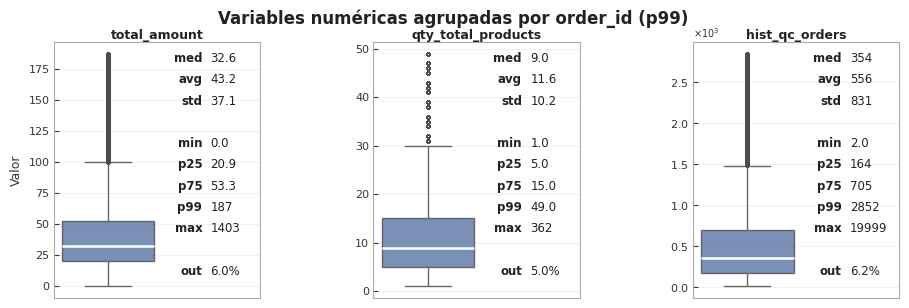

In [37]:
# Grafico de variables cuantitativas en Boxplots

from matplotlib.gridspec import GridSpec

COLOR = sns.color_palette('deep')[0]
FS    = 8.5

def fmt(v):
    return f"{v:.0f}" if abs(v) >= 100 else f"{v:.1f}"

fig = plt.figure(figsize=(9.5, 3.2), facecolor='white')
fig.suptitle('Variables numéricas agrupadas por order_id (p99)',
             fontsize=12, fontweight='bold', color='#222222', y=0.98)

gs = GridSpec(1, 3, figure=fig,
              left=0.08, right=0.97, bottom=0.08, top=0.88,
              wspace=0.55)

ax_list = [fig.add_subplot(gs[0, i]) for i in range(3)]

for ax, col in zip(ax_list, num_cols):
    m = meta[col]
    s = m['serie']

    sns.boxplot(y=m['data'], ax=ax, color=COLOR, width=0.85,
                medianprops=dict(color='white', linewidth=1.8),
                flierprops=dict(marker='o', markersize=2, alpha=0.2, color=COLOR),
                boxprops=dict(alpha=0.8),
                whiskerprops=dict(color='#666666', linewidth=1.0),
                capprops=dict(color='#666666', linewidth=1.0))

    ax.set_xlim(-0.5, 1.4)
    ax.set_title(col, fontsize=9, fontweight='bold', color='#222222', pad=2)
    ax.set_ylabel('Valor' if ax == ax_list[0] else '', fontsize=9, color='#333333')
    ax.set_xlabel('')
    ax.set_xticks([])
    ax.tick_params(axis='y', labelsize=8, colors='#333333', direction='in', pad=3)
    ax.set_facecolor('white')
    ax.set_axisbelow(True)
    ax.grid(axis='y', color='#EEEEEE', linewidth=0.6)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('#AAAAAA')
        spine.set_linewidth(0.8)

    if m['data'].max() > 1000:
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)
        ax.yaxis.get_offset_text().set_fontsize(7)

    LEND = 0.72; VSTART = 0.76
    stats_items = [
        ('med', fmt(s.median())),
        ('avg', fmt(s.mean())),
        ('std', fmt(s.std())),
        ('sep', None),
        ('min', fmt(s.min())),
        ('p25', fmt(m['Q1'])),
        ('p75', fmt(m['Q3'])),
        ('p99', fmt(m['p99'])),
        ('max', fmt(s.max())),
        ('sep', None),
        ('out', f"{m['n_out']/len(s)*100:.1f}%"),
    ]

    y_pos, step = 0.96, 0.083
    for label, value in stats_items:
        if label == 'sep':
            y_pos -= step
            continue
        ax.text(LEND, y_pos, label, transform=ax.transAxes,
                fontsize=FS, fontweight='bold',
                va='top', ha='right', color='#222222')
        ax.text(VSTART, y_pos, value, transform=ax.transAxes,
                fontsize=FS,
                va='top', ha='left', color='#222222')
        y_pos -= step

sns.reset_defaults()
plt.show()

In [38]:
#Distribución de ordenes según booleanas. (has discount,  is_food)

vc_disc  = df_orders['has_discount'].value_counts()
pct_disc = (vc_disc / len(df_orders) * 100).round(1)

vc_food  = df_orders['is_food'].value_counts()
pct_food = (vc_food / len(df_orders) * 100).round(1)

print("\nhas_discount:")
print(pd.DataFrame({'n': vc_disc, '%': pct_disc}).to_string())
print("\nis_food:")
print(pd.DataFrame({'n': vc_food, '%': pct_food}).to_string())


has_discount:
                    n     %
has_discount               
True          2100386  84.9
False          373906  15.1

is_food:
               n     %
is_food               
True     2456996  99.3
False      17296   0.7


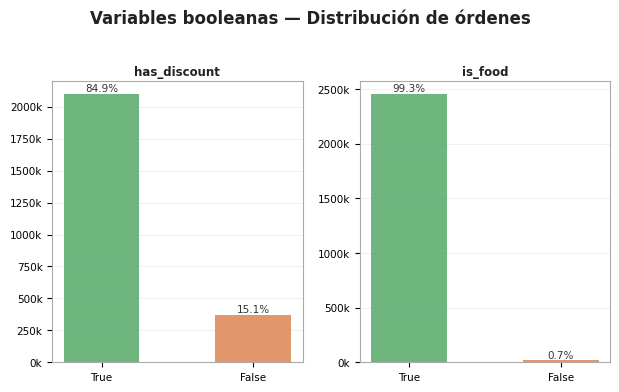

In [40]:
#Gráfico variables booleanas

import matplotlib.ticker as mticker

PAL   = sns.color_palette('deep')
BLUE  = PAL[0]

fig, axes = plt.subplots(1, 2, figsize=(6.3, 3.8), facecolor='white')
fig.suptitle('Variables booleanas — Distribución de órdenes',
             fontsize=12, fontweight='bold', color='#222222', y=1.02)

ax_disc, ax_food = axes

def style_ax(ax, fs=8):
    ax.set_facecolor('white')
    ax.set_axisbelow(True)
    ax.grid(axis='y', color='#EEEEEE', linewidth=0.6)
    ax.tick_params(labelsize=fs)
    for sp in ax.spines.values():
        sp.set_edgecolor('#AAAAAA'); sp.set_linewidth(0.8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))

# has_discount
c_bool = [PAL[2] if v else PAL[1] for v in vc_disc.index]
bars2  = ax_disc.bar([str(v) for v in vc_disc.index], vc_disc.values, color=c_bool, alpha=0.85, width=0.5)
for bar, pct in zip(bars2, pct_disc.values):
    ax_disc.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=7.5, color='#333333')
ax_disc.set_title('has_discount', fontsize=8.5, fontweight='bold', color='#222222', pad=4)
style_ax(ax_disc, fs=7.5)

# is_food
c_food = [PAL[2] if v else PAL[1] for v in vc_food.index]
bars3  = ax_food.bar([str(v) for v in vc_food.index], vc_food.values, color=c_food, alpha=0.85, width=0.5)
for bar, pct in zip(bars3, pct_food.values):
    ax_food.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=7.5, color='#333333')
ax_food.set_title('is_food', fontsize=8.5, fontweight='bold', color='#222222', pad=4)
style_ax(ax_food, fs=7.5)

plt.tight_layout()
sns.reset_defaults()
plt.show()

In [42]:
#Distribución de ordenes según categoricas (businees type)

vc_bt    = df_orders['business_type_name'].value_counts()
pct_bt   = (vc_bt / len(df_orders) * 100).round(1)

print("business_type_name:")
print(pd.DataFrame({'n': vc_bt, '%': pct_bt}).to_string())

business_type_name:
                          n     %
business_type_name               
Market              2175267  87.9
Kiosks               298292  12.1
Shop                    733   0.0


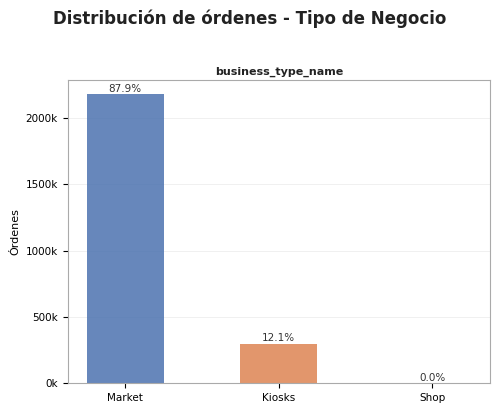

In [52]:
#Gráfico variables cualitativas: Bussines type

import matplotlib.ticker as mticker

PAL  = sns.color_palette('deep')

fig, ax_bt = plt.subplots(1, 1, figsize=(5.1, 4), facecolor='white')
fig.suptitle('Distribución de órdenes - Tipo de Negocio',
             fontsize=12, fontweight='bold', color='#222222', y=1.02)

def style_ax(ax, fs=8):
    ax.set_facecolor('white')
    ax.set_axisbelow(True)
    ax.grid(axis='y', color='#EEEEEE', linewidth=0.6)
    ax.tick_params(labelsize=fs)
    for sp in ax.spines.values():
        sp.set_edgecolor('#AAAAAA'); sp.set_linewidth(0.8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))

# business_type_name
colors = [PAL[i % len(PAL)] for i in range(len(vc_bt))]
bars1  = ax_bt.bar(vc_bt.index, vc_bt.values, color=colors, alpha=0.85, width=0.5)
for bar, pct in zip(bars1, pct_bt.values):
    ax_bt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1500,
               f'{pct:.1f}%', ha='center', va='bottom', fontsize=7.5, color='#333333')
ax_bt.set_title('business_type_name', fontsize=8, fontweight='bold', color='#222222', pad=4)
ax_bt.set_ylabel('Órdenes', fontsize=8)
style_ax(ax_bt, fs=7.5)

plt.tight_layout()
sns.reset_defaults()
plt.show()

In [59]:
# Categorías a nivel de orden: Presencia de categorias por ordenes (cuántas órdenes incluyen al menos un producto de cada categoría)

orders_per_cat = (
    df.groupby('category')['order_id']
    .nunique()
    .sort_values(ascending=False)
)
total_orders = df_orders['order_id'].nunique()
pct_cat_ord  = (orders_per_cat / total_orders * 100).round(2)

# Pareto: peso relativo y cobertura acumulada
pct_norm   = pct_cat_ord / pct_cat_ord.sum() * 100
cumulative = pct_norm.cumsum()

n_cats_50 = int((cumulative <= 50).sum()) + 1
n_cats_80 = int((cumulative <= 80).sum()) + 1

# Categorías ancla: presencia > 20% de las órdenes
ancla      = pct_cat_ord[pct_cat_ord >= 20]
n_ancla    = len(ancla)
cob_ancla  = cumulative.iloc[n_ancla - 1]

cat_ord_df = pd.DataFrame({'ordenes': orders_per_cat, '%': pct_cat_ord})

print(f'Total órdenes:     {total_orders:,}')
print(f'Total categorías:  {len(orders_per_cat)}')
print(f'\nCategorías ancla (presencia >= 20%):')
print(cat_ord_df[pct_cat_ord >= 20].to_string())
print(f'  → {n_ancla} categorías = {cob_ancla:.1f}% de la cobertura acumulada')
print(f'\nCortes de Pareto:')
print(f'  50% de cobertura: {n_cats_50} categorías')
print(f'  80% de cobertura: {n_cats_80} categorías')
print(f'\nDistribución completa (62 categorías):')
pd.set_option('display.max_rows', None)
print(cat_ord_df.to_string())
pd.reset_option('display.max_rows')

Total órdenes:     2,474,292
Total categorías:  61

Categorías ancla (presencia >= 20%):
              ordenes      %
category                    
lacteos        712178  28.78
pagnificados   699071  28.25
quesos         609961  24.65
bebidas        590273  23.86
verduras       564931  22.83
snacks         555119  22.44
  → 6 categorías = 35.2% de la cobertura acumulada

Cortes de Pareto:
  50% de cobertura: 11 categorías
  80% de cobertura: 26 categorías

Distribución completa (62 categorías):
                            ordenes      %
category                                  
lacteos                      712178  28.78
pagnificados                 699071  28.25
quesos                       609961  24.65
bebidas                      590273  23.86
verduras                     564931  22.83
snacks                       555119  22.44
general                      411867  16.65
condimentos especias         371899  15.03
cuidado personal             370873  14.99
frutas                      

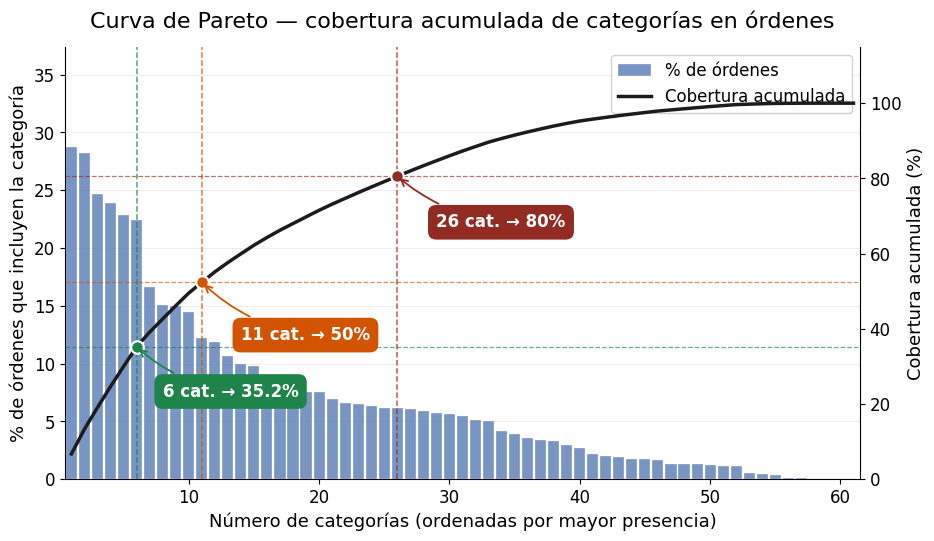

In [63]:
# Categorías a nivel de orden: GRAFICO cuántas órdenes incluyen al menos un producto de cada categoría
plt.close('all')
PAL   = sns.color_palette('deep')
BLUE  = PAL[0]
GREEN = '#1E8449'
ORG   = '#D35400'
RED   = '#922B21'

cumulative_vals = cumulative.values
bar_vals        = pct_cat_ord.values
x = list(range(1, len(cumulative_vals) + 1))

fig, ax1 = plt.subplots(figsize=(24/2.54, 14/2.54))
ax2 = ax1.twinx()

fig.patch.set_facecolor('white')
ax1.set_facecolor('white')
ax1.set_axisbelow(True)
ax1.grid(axis='y', color='#EEEEEE', linewidth=0.7, zorder=0)
ax1.spines[['top', 'right']].set_visible(False)
ax2.spines[['top', 'left', 'bottom']].set_visible(False)

# Barras — % real de órdenes
ax1.bar(x, bar_vals, color=BLUE, alpha=0.75, width=0.85,
        edgecolor='white', linewidth=0.3,
        label='% de órdenes', zorder=2)
ax1.set_ylabel('% de órdenes que incluyen la categoría', fontsize=13)
ax1.set_ylim(0, max(bar_vals) * 1.3)
ax1.tick_params(axis='y', labelsize=12)

# Curva acumulada
ax2.plot(x, cumulative_vals, color='#1C1C1C', linewidth=2.5,
         label='Cobertura acumulada', zorder=4)
ax2.set_ylabel('Cobertura acumulada (%)', fontsize=13)
ax2.set_ylim(0, 115)
ax2.tick_params(axis='y', labelsize=12)

# Puntos y anotaciones
puntos = [
    (n_ancla,   cumulative_vals[n_ancla - 1],   GREEN, f'{n_ancla} cat. → {cob_ancla:.1f}%',  (8,  22)),
    (n_cats_50, cumulative_vals[n_cats_50 - 1], ORG,   f'{n_cats_50} cat. → 50%',             (14, 37)),
    (n_cats_80, cumulative_vals[n_cats_80 - 1], RED,   f'{n_cats_80} cat. → 80%',             (29, 67)),
]

for px, py, col, label, (tx, ty) in puntos:
    ax2.axvline(px, color=col, linestyle='--', linewidth=1.1, alpha=0.75, zorder=3)
    ax2.axhline(py, color=col, linestyle='--', linewidth=0.9, alpha=0.65, zorder=3)
    ax2.plot(px, py, 'o', color=col, markersize=9, zorder=6,
             markeredgecolor='white', markeredgewidth=1.5)
    ax2.annotate(
        label,
        xy=(px, py), xytext=(tx, ty),
        fontsize=12, color='white', fontweight='bold',
        arrowprops=dict(arrowstyle='->', color=col, lw=1.3,
                        connectionstyle='arc3,rad=-0.15'),
        bbox=dict(boxstyle='round,pad=0.5', fc=col, ec='none', alpha=1.0),
        zorder=7
    )

# Leyenda
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper right', fontsize=12, framealpha=0.9)

ax1.set_xlabel('Número de categorías (ordenadas por mayor presencia)', fontsize=13)
ax1.set_xlim(0.5, len(x) + 0.5)
ax1.tick_params(axis='x', labelsize=12)

plt.title('Curva de Pareto — cobertura acumulada de categorías en órdenes',
          fontsize=16, pad=14)
plt.tight_layout()
plt.show()

In [54]:
#Variables temporales: Estadisticos - Analizo distribución de ordenes segun horas y dias

day_order  = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_labels = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

vc_hour   = df_orders['hour'].value_counts().sort_index()
vc_week   = df_orders['weekday'].value_counts().reindex(day_order)
mean_day  = vc_week.mean()
deviation = vc_week - mean_day

print("Órdenes por hora:")
print(vc_hour.to_string())
print(f"\nMedia diaria: {mean_day:,.0f} órdenes")
print("\nDesviación vs media por día:")
print(deviation.to_string())

Órdenes por hora:
hour
0      16949
1       5119
2        851
3        216
4        120
5        167
6        407
7       4104
8      39865
9      82597
10    125785
11    159388
12    176493
13    161695
14    134322
15    121499
16    131638
17    168357
18    215351
19    276877
20    270903
21    196277
22    126203
23     59109

Media diaria: 353,470 órdenes

Desviación vs media por día:
weekday
Monday       44767.714286
Tuesday     -39376.285714
Wednesday   -52792.285714
Thursday    -50496.285714
Friday      -18669.285714
Saturday     24602.714286
Sunday       91963.714286


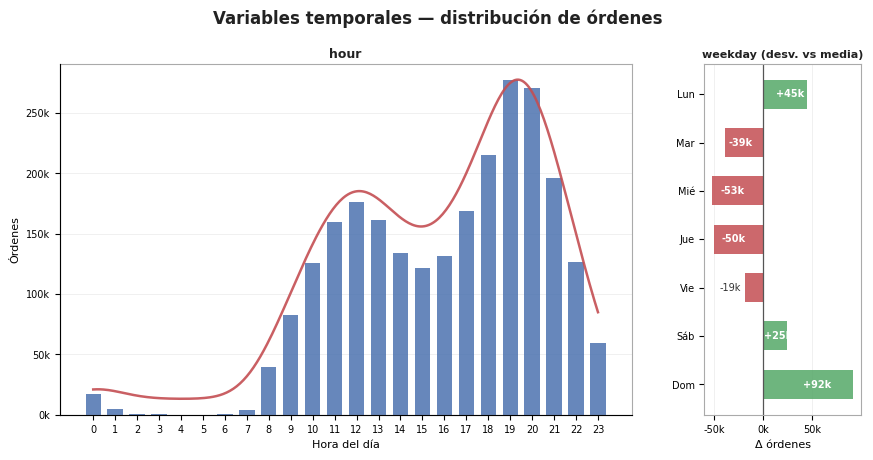

In [66]:
#Gráfico distribucion de ordenes segun horas y dias. Uso media de dias para remarcar dias con mas ordenes

from scipy.stats import gaussian_kde

PAL   = sns.color_palette('deep')
BLUE  = PAL[0]; RED = PAL[3]; GREEN = PAL[2]; RED_D = PAL[3]
colors = [GREEN if v >= 0 else RED_D for v in deviation.values]

fig = plt.figure(figsize=(9, 4.5), facecolor='white')
fig.suptitle('Variables temporales — distribución de órdenes',
             fontsize=12, fontweight='bold', color='#222222', y=1.02)

gs = GridSpec(1, 2, figure=fig,
              width_ratios=[5.5, 1.5],
              left=0.08, right=0.97, bottom=0.12, top=0.90, wspace=0.20)

ax_h = fig.add_subplot(gs[0, 0])
ax_w = fig.add_subplot(gs[0, 1])

# --- hour: barras + KDE ---
ax_h.set_facecolor('white')
ax_h.set_axisbelow(True)
ax_h.grid(axis='y', color='#EEEEEE', linewidth=0.6)
ax_h.bar(vc_hour.index, vc_hour.values, color=BLUE, alpha=0.85, width=0.7)

ax_h2 = ax_h.twinx()
kde = gaussian_kde(df_orders['hour'].dropna().values, bw_method=0.25)
x_kde = np.linspace(0, 23, 300)
ax_h2.plot(x_kde, kde(x_kde), color=RED, linewidth=1.8, alpha=0.9)
ax_h2.set_yticks([]); ax_h2.set_ylabel('')
ax_h2.spines['right'].set_visible(False); ax_h2.spines['top'].set_visible(False)

ax_h.set_title('hour', fontsize=9, fontweight='bold', color='#222222', pad=4)
ax_h.set_xlabel('Hora del día', fontsize=8)
ax_h.set_ylabel('Órdenes', fontsize=8)
ax_h.set_xticks(range(0, 24))
ax_h.tick_params(labelsize=7)
ax_h.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))
for sp in ax_h.spines.values():
    sp.set_edgecolor('#AAAAAA'); sp.set_linewidth(0.8)

# --- weekday: barras de desviacion ---
ax_w.set_facecolor('white')
ax_w.set_axisbelow(True)
ax_w.grid(axis='x', color='#EEEEEE', linewidth=0.6)
bars = ax_w.barh(day_labels, deviation.values, color=colors, alpha=0.85, height=0.6)
ax_w.invert_yaxis()
ax_w.axvline(0, color='#555555', linewidth=0.9)

max_abs = deviation.abs().max()
for bar, val in zip(bars, deviation.values):
    label = f'{val/1000:+.0f}k'
    if abs(val) > max_abs * 0.25:
        ax_w.text(val * 0.6, bar.get_y() + bar.get_height()/2, label,
                  va='center', ha='center', fontsize=7,
                  color='white', fontweight='bold')
    else:
        ax_w.text(val + (4000 if val >= 0 else -4000), bar.get_y() + bar.get_height()/2, label,
                  va='center', ha='left' if val >= 0 else 'right',
                  fontsize=7, color='#333333')

ax_w.set_title('weekday (desv. vs media)', fontsize=8, fontweight='bold', color='#222222', pad=4)
ax_w.set_xlabel('Δ órdenes', fontsize=8)
ax_w.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))
ax_w.tick_params(labelsize=7)
for sp in ax_w.spines.values():
    sp.set_edgecolor('#AAAAAA'); sp.set_linewidth(0.8)

plt.show()

In [ ]:
# Distribución de ordenes segun partners. Agrupo por Bins

orders_por_partner = df_orders.groupby("partner_id").size().sort_values(ascending=False)

cortes  = [1, 2, 6, 11, 51, 101, orders_por_partner.max() + 1]
etiq    = ["1", "2-5", "6-10", "11-50", "51-100", "100+"]
dist_p  = pd.cut(orders_por_partner, bins=cortes, labels=etiq, right=False).value_counts().reindex(etiq)
dist_pct_p = (dist_p / dist_p.sum() * 100).round(1)

print(f"Partners únicos: {len(orders_por_partner):,}")
print(f"Órdenes por partner — min: {orders_por_partner.min():,}  max: {orders_por_partner.max():,}  mediana: {orders_por_partner.median():.0f}")
print()
print("Distribución de partners por volumen de órdenes:")
print(pd.DataFrame({"partners": dist_p, "%": dist_pct_p}).to_string())
print()
n_pocos = (orders_por_partner <= 5).sum()
print(f"Partners con 5 o menos órdenes: {n_pocos:,}  ({n_pocos/len(orders_por_partner)*100:.1f}% de los partners)")
print(f"Órdenes que representan: {orders_por_partner[orders_por_partner <= 5].sum():,}  ({orders_por_partner[orders_por_partner <= 5].sum()/len(df_orders)*100:.2f}% del total)")

In [67]:
# Analizo parteners con  mayores ordenes

# --- partner_id ---
orders_per_partner = df_orders.groupby('partner_id').size().sort_values(ascending=False)
cumsum_partner     = orders_per_partner.cumsum() / orders_per_partner.sum() * 100

n_50 = (cumsum_partner <= 50).sum() + 1
n_80 = (cumsum_partner <= 80).sum() + 1
top20_partners = orders_per_partner.head(20)
top20_pct      = (top20_partners / len(df_orders) * 100).round(1)

print(f"Partners totales: {len(orders_per_partner):,}")
print(f"Partners que concentran el 50% de las órdenes: {n_50:,}  ({n_50/len(orders_per_partner)*100:.1f}%)")
print(f"Partners que concentran el 80% de las órdenes: {n_80:,}  ({n_80/len(orders_per_partner)*100:.1f}%)")
print(f"\nTop 20 partners — órdenes y % del total:")
print(pd.DataFrame({'órdenes': top20_partners, '% total': top20_pct}).to_string())

# --- user_id ---
orders_per_user = df_orders.groupby('user_id').size().sort_values(ascending=False)

bins   = [1, 2, 3, 6, 11, orders_per_user.max() + 1]
labels = ['1', '2', '3–5', '6–10', '11+']
dist_usuario = pd.cut(orders_per_user, bins=bins, labels=labels, right=False).value_counts().reindex(labels)
dist_pct     = (dist_usuario / dist_usuario.sum() * 100).round(1)

print(f"\nUsuarios totales: {len(orders_per_user):,}")
print(f"\nDistribución de órdenes por usuario:")
print(pd.DataFrame({'usuarios': dist_usuario, '%': dist_pct}).to_string())

Partners totales: 2,261
Partners que concentran el 50% de las órdenes: 47  (2.1%)
Partners que concentran el 80% de las órdenes: 187  (8.3%)

Top 20 partners — órdenes y % del total:
            órdenes  % total
partner_id                  
PTN_00003     46183      1.9
PTN_00033     39575      1.6
PTN_00056     34867      1.4
PTN_00161     34264      1.4
PTN_00122     34181      1.4
PTN_00391     33910      1.4
PTN_00048     33594      1.4
PTN_00070     32905      1.3
PTN_00024     31822      1.3
PTN_00273     30183      1.2
PTN_00362     30072      1.2
PTN_00120     29940      1.2
PTN_00339     29469      1.2
PTN_00151     28888      1.2
PTN_00080     28544      1.2
PTN_00014     28513      1.2
PTN_00204     28404      1.1
PTN_00006     28173      1.1
PTN_00062     27452      1.1
PTN_00298     26578      1.1

Usuarios totales: 652,879

Distribución de órdenes por usuario:
      usuarios     %
1       168200  25.8
2       169573  26.0
3–5     190913  29.2
6–10     85941  13.2
11+      

In [68]:
# Variable Product_id. Analizo como se distribuyen los productos dentro de las ordenes

total_products = df['product_id'].nunique()
total_ord = df_orders['order_id'].nunique()

top_prod = (
    df.groupby('product_id')['order_id']
    .nunique()
    .sort_values(ascending=False)
)

print(f'Productos únicos: {total_products:,}')
print(f'\nTop 5 productos (% de órdenes que los incluyen):')
print((top_prod.head(5) / total_ord * 100).round(2).to_string())
print(f'\nProductos presentes en >10% de órdenes: {(top_prod / total_ord >= 0.10).sum()}')
print(f'Productos presentes en >1% de órdenes:  {(top_prod / total_ord >= 0.01).sum()}')
print(f'Productos presentes en <=1% de órdenes: {(top_prod / total_ord < 0.01).sum()} '
      f'({(top_prod / total_ord < 0.01).mean()*100:.1f}% del catálogo)')

Productos únicos: 1,490,255

Top 5 productos (% de órdenes que los incluyen):
product_id
PRD_01851    0.20
PRD_01939    0.18
PRD_12875    0.16
PRD_12940    0.15
PRD_06940    0.14

Productos presentes en >10% de órdenes: 0
Productos presentes en >1% de órdenes:  0
Productos presentes en <=1% de órdenes: 1490255 (100.0% del catálogo)


In [69]:
# user_id — Analizo distribución de frecuencia de órdenes por usuario


user_orders = df_orders.groupby('user_id')['order_id'].nunique()

print(f'Usuarios únicos: {user_orders.shape[0]:,}')
print(f'Mediana de órdenes por usuario: {user_orders.median():.0f}')
print(f'Máximo de órdenes por usuario:  {user_orders.max()}')
print(f'\nDesglose por frecuencia:')
print(f'  1 orden (one-shot):   {(user_orders == 1).sum():,} usuarios ({(user_orders == 1).mean()*100:.1f}%)')
print(f'  2-4 órdenes:          {((user_orders >= 2) & (user_orders <= 4)).sum():,} usuarios ({((user_orders >= 2) & (user_orders <= 4)).mean()*100:.1f}%)')
print(f'  5-9 órdenes:          {((user_orders >= 5) & (user_orders <= 9)).sum():,} usuarios ({((user_orders >= 5) & (user_orders <= 9)).mean()*100:.1f}%)')
print(f'  10+ órdenes:          {(user_orders >= 10).sum():,} usuarios ({(user_orders >= 10).mean()*100:.1f}%)')
print(f'  20+ órdenes:          {(user_orders >= 20).sum():,} usuarios ({(user_orders >= 20).mean()*100:.1f}%)')

Usuarios únicos: 652,879
Mediana de órdenes por usuario: 2
Máximo de órdenes por usuario:  153

Desglose por frecuencia:
  1 orden (one-shot):   168,200 usuarios (25.8%)
  2-4 órdenes:          320,509 usuarios (49.1%)
  5-9 órdenes:          116,862 usuarios (17.9%)
  10+ órdenes:          47,308 usuarios (7.2%)
  20+ órdenes:          7,208 usuarios (1.1%)


## **05.  Analisis Bivariado**

## *Resumen*
_______________________

Variables cuantitativas
|Tarea|Utilidad|Estado|
|---|---|---|
|Completar